# Clean IRIS Random-Walk Break-Even Model

This notebook targets parity with the working `statsmodels` local-level specification using an IRIS system specification rather than measurement exogenous regressors.

The key modeling lesson is that IRIS behaves much more reliably here when every time-varying object is represented inside the model system as either a transition variable or a measurement variable.

So instead of writing a local level with exogenous regressors directly on the measurement RHS, we augment the state vector and observe the regressors through identity measurement equations.

Main measurement equation:

U_t = c_t + b_0 yy0_t + b_1 yy1_t + b_2 yy2_t + d_2 dd2_t + d_3 dd3_t + eps_t

Identity measurements for the observed regressors:

Y_t = yy0_t, \quad Y_{t-1} = yy1_t, \quad Y_{t-2} = yy2_t, \quad D_{2020Q2,t} = dd2_t, \quad D_{2020Q3,t} = dd3_t

Random-walk transitions:

c_t = c_{t-1} + eta^c_t

yy0_t = yy0_{t-1} + eta^{y0}_t, \quad yy1_t = yy1_{t-1} + eta^{y1}_t, \quad yy2_t = yy2_{t-1} + eta^{y2}_t

dd2_t = dd2_{t-1} + eta^{d2}_t, \quad dd3_t = dd3_{t-1} + eta^{d3}_t

The intercept state innovation is fixed at `0.05 * sigma_ols`, and the notebook compares the IRIS smoothed intercept state directly against the exported `statsmodels` reference sample and decomposition.

In [1]:
from pathlib import Path

import irispie as ir
from irispie import ModelSource
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.optimize import minimize

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / 'data' / 'prepared' / 'analysis_dataset_quarterly.csv'
DEBUG_DIR = PROJECT_ROOT / 'outputs' / 'debug_irispie_parity'
REFERENCE_SAMPLE_PATH = DEBUG_DIR / 'y_to_u_sample.csv'
REFERENCE_DECOMP_PATH = DEBUG_DIR / 'y_to_u_state_decomposition.csv'
OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'time_varying_break_even_irispie_clean_rw.csv'

## Load Dataset

In [2]:
analysis_df = pd.read_csv(DATA_PATH, parse_dates=['date']).sort_values('date').reset_index(drop=True)
reference_sample = pd.read_csv(REFERENCE_SAMPLE_PATH, parse_dates=['date']).sort_values('date').reset_index(drop=True)
reference_decomp = pd.read_csv(REFERENCE_DECOMP_PATH, parse_dates=['date']).sort_values('date').reset_index(drop=True)
state_df = reference_sample[['date', 'U', 'Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']].copy()
state_df.head()

,date,U,Y,Y_lag1,Y_lag2,d2020q2,d2020q3
0,1992-07-01,0.459030,-0.726074,-0.085709,0.570575,0.0,0.0
1,1992-10-01,0.586036,-0.501668,-0.726074,-0.085709,0.0,0.0
2,1993-01-01,0.505514,-0.332376,-0.501668,-0.726074,0.0,0.0
3,1993-04-01,0.544164,0.917484,-0.332376,-0.501668,0.0,0.0
4,1993-07-01,0.405125,0.381316,0.917484,-0.332376,0.0,0.0


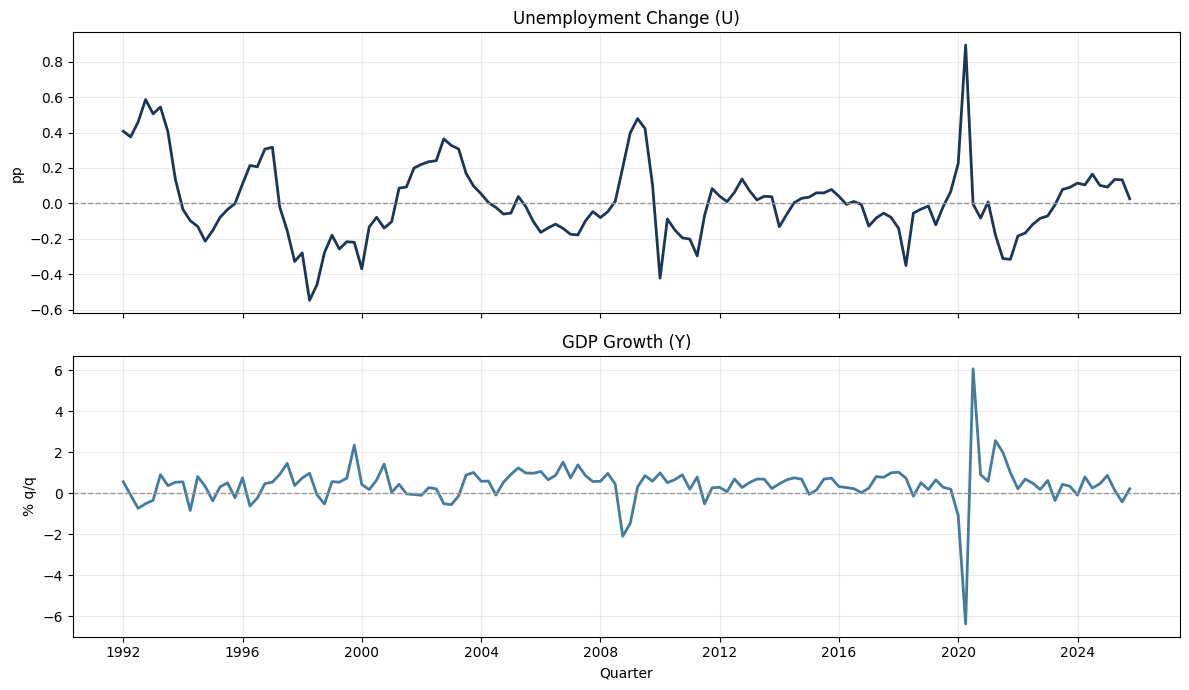

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(analysis_df['date'], analysis_df['U'], color='#1d3557', linewidth=2)
axes[0].axhline(0, color='#999999', linestyle='--', linewidth=1)
axes[0].set_title('Unemployment Change (U)')
axes[0].set_ylabel('pp')
axes[0].grid(alpha=0.25)

axes[1].plot(analysis_df['date'], analysis_df['Y'], color='#457b9d', linewidth=2)
axes[1].axhline(0, color='#999999', linestyle='--', linewidth=1)
axes[1].set_title('GDP Growth (Y)')
axes[1].set_ylabel('% q/q')
axes[1].set_xlabel('Quarter')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Static OLS Benchmark

In [4]:
X_ols = sm.add_constant(state_df[['Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']])
ols_result = sm.OLS(state_df['U'], X_ols).fit()
sigma_ols = float(ols_result.resid.std(ddof=int(ols_result.df_model) + 1))
std_eta_fixed = 0.05 * sigma_ols
beta_sum_ols = float(ols_result.params['Y'] + ols_result.params['Y_lag1'] + ols_result.params['Y_lag2'])
static_break_even_qoq = -ols_result.params['const'] / beta_sum_ols
static_break_even_annualized = ((1 + static_break_even_qoq / 100) ** 4 - 1) * 100

pd.DataFrame({
    'parameter': ['const', 'b0', 'b1', 'b2', 'd2020q2', 'd2020q3', 'sigma_ols', 'std_eta_fixed', 'beta_sum_ols', 'static_break_even_qoq', 'static_break_even_annualized'],
    'estimate': [
        ols_result.params['const'],
        ols_result.params['Y'],
        ols_result.params['Y_lag1'],
        ols_result.params['Y_lag2'],
        ols_result.params['d2020q2'],
        ols_result.params['d2020q3'],
        sigma_ols,
        std_eta_fixed,
        beta_sum_ols,
        static_break_even_qoq,
        static_break_even_annualized,
    ],
})

,parameter,estimate
0,const,0.125382
1,b0,-0.087537
2,b1,-0.109266
3,b2,-0.074520
4,d2020q2,0.108142
5,d2020q3,-0.371930
6,sigma_ols,0.157562
7,std_eta_fixed,0.007878
8,beta_sum_ols,-0.271323
9,static_break_even_qoq,0.462112


## IRIS Augmented-State Model

In [5]:
start_period = ir.qq(int(state_df.loc[0, 'date'].year), int((state_df.loc[0, 'date'].month - 1) / 3 + 1))
end_period = ir.qq(int(state_df.loc[state_df.index[-1], 'date'].year), int((state_df.loc[state_df.index[-1], 'date'].month - 1) / 3 + 1))
span = ir.periods_from_to(start_period, end_period)

std_eta_y0 = float(np.std(np.diff(state_df['Y'].to_numpy()), ddof=1))
std_eta_y1 = float(np.std(np.diff(state_df['Y_lag1'].to_numpy()), ddof=1))
std_eta_y2 = float(np.std(np.diff(state_df['Y_lag2'].to_numpy()), ddof=1))
std_eta_d2 = max(float(np.std(np.diff(state_df['d2020q2'].to_numpy()), ddof=1)), 1e-6)
std_eta_d3 = max(float(np.std(np.diff(state_df['d2020q3'].to_numpy()), ddof=1)), 1e-6)

model_source = ModelSource.from_lists(
    transition_variables=[('', 'c', ()), ('', 'yy0', ()), ('', 'yy1', ()), ('', 'yy2', ()), ('', 'dd2', ()), ('', 'dd3', ())],
    measurement_variables=[('', 'U_obs', ()), ('', 'Y0_obs', ()), ('', 'Y1_obs', ()), ('', 'Y2_obs', ()), ('', 'D2020Q2_obs', ()), ('', 'D2020Q3_obs', ())],
    parameters=[('', 'b0', ()), ('', 'b1', ()), ('', 'b2', ()), ('', 'd2', ()), ('', 'd3', ())],
    unanticipated_shocks=[('', 'eta_c', ()), ('', 'eta_y0', ()), ('', 'eta_y1', ()), ('', 'eta_y2', ()), ('', 'eta_d2', ()), ('', 'eta_d3', ())],
    measurement_shocks=[('', 'eps', ())],
    transition_equations=[
        ('', ('c = c[-1] + eta_c', 'c = c'), ()),
        ('', ('yy0 = yy0[-1] + eta_y0', 'yy0 = yy0'), ()),
        ('', ('yy1 = yy1[-1] + eta_y1', 'yy1 = yy1'), ()),
        ('', ('yy2 = yy2[-1] + eta_y2', 'yy2 = yy2'), ()),
        ('', ('dd2 = dd2[-1] + eta_d2', 'dd2 = dd2'), ()),
        ('', ('dd3 = dd3[-1] + eta_d3', 'dd3 = dd3'), ()),
    ],
    measurement_equations=[
        ('', ('U_obs = c + b0*yy0 + b1*yy1 + b2*yy2 + d2*dd2 + d3*dd3 + eps', 'U_obs = c + b0*yy0 + b1*yy1 + b2*yy2 + d2*dd2 + d3*dd3'), ()),
        ('', ('Y0_obs = yy0', 'Y0_obs = yy0'), ()),
        ('', ('Y1_obs = yy1', 'Y1_obs = yy1'), ()),
        ('', ('Y2_obs = yy2', 'Y2_obs = yy2'), ()),
        ('', ('D2020Q2_obs = dd2', 'D2020Q2_obs = dd2'), ()),
        ('', ('D2020Q3_obs = dd3', 'D2020Q3_obs = dd3'), ()),
    ],
)

input_db = ir.Databox.from_dict({
    'U_obs': ir.Series.from_start_and_array(start_period, state_df['U'].to_numpy()),
    'Y0_obs': ir.Series.from_start_and_array(start_period, state_df['Y'].to_numpy()),
    'Y1_obs': ir.Series.from_start_and_array(start_period, state_df['Y_lag1'].to_numpy()),
    'Y2_obs': ir.Series.from_start_and_array(start_period, state_df['Y_lag2'].to_numpy()),
    'D2020Q2_obs': ir.Series.from_start_and_array(start_period, state_df['d2020q2'].to_numpy()),
    'D2020Q3_obs': ir.Series.from_start_and_array(start_period, state_df['d2020q3'].to_numpy()),
})

def build_model(theta):
    b0, b1, b2, d2, d3, log_std_eps = theta
    model = ir.Model.from_source(model_source, linear=True, flat=True)
    model.assign(
        c=0.0,
        yy0=float(state_df.loc[0, 'Y']),
        yy1=float(state_df.loc[0, 'Y_lag1']),
        yy2=float(state_df.loc[0, 'Y_lag2']),
        dd2=float(state_df.loc[0, 'd2020q2']),
        dd3=float(state_df.loc[0, 'd2020q3']),
        U_obs=0.0,
        Y0_obs=0.0,
        Y1_obs=0.0,
        Y2_obs=0.0,
        D2020Q2_obs=0.0,
        D2020Q3_obs=0.0,
        b0=float(b0),
        b1=float(b1),
        b2=float(b2),
        d2=float(d2),
        d3=float(d3),
        std_eta_c=float(std_eta_fixed),
        std_eta_y0=float(std_eta_y0),
        std_eta_y1=float(std_eta_y1),
        std_eta_y2=float(std_eta_y2),
        std_eta_d2=float(std_eta_d2),
        std_eta_d3=float(std_eta_d3),
        std_eps=float(np.exp(log_std_eps)),
    )
    model.steady(linear=True, flat=True)
    model.solve(linear=True, flat=True)
    return model

def objective(theta):
    try:
        fitted_model = build_model(theta)
        _, info = fitted_model.kalman_filter(
            input_db,
            span,
            deviation=False,
            return_=('smooth',),
            return_info=True,
            diffuse_method='fixed_unknown',
        )
        return float(info['neg_log_likelihood'])
    except Exception:
        return 1e9

theta0 = np.array([
    float(ols_result.params['Y']),
    float(ols_result.params['Y_lag1']),
    float(ols_result.params['Y_lag2']),
    float(ols_result.params['d2020q2']),
    float(ols_result.params['d2020q3']),
    np.log(max(float(ols_result.resid.std(ddof=1)), 1e-4)),
])

result = minimize(
    objective,
    theta0,
    method='L-BFGS-B',
    bounds=[(-2.0, 2.0), (-2.0, 2.0), (-2.0, 2.0), (-5.0, 5.0), (-5.0, 5.0), (np.log(1e-4), np.log(5.0))],
    options={'maxiter': 200},
)
result

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 468.3436553117441
        x: [-8.589e-02 -1.088e-01 -7.386e-02  1.158e-01 -3.832e-01
            -1.906e+00]
      nit: 21
      jac: [-6.662e-03  4.491e-04 -1.285e-03  6.821e-05 -6.480e-04
             2.080e-03]
     nfev: 203
     njev: 29
 hess_inv: <6x6 LbfgsInvHessProduct with dtype=float64>

In [6]:
b0_hat, b1_hat, b2_hat, d2_hat, d3_hat, log_std_eps_hat = result.x
std_eps_hat = float(np.exp(log_std_eps_hat))
model_tv = build_model(result.x)
beta_sum_hat = float(b0_hat + b1_hat + b2_hat)

param_table = pd.DataFrame({
    'parameter': ['b0', 'b1', 'b2', 'd2', 'd3', 'std_eta_fixed', 'std_eps', 'beta_sum_hat', 'neg_log_likelihood'],
    'estimate': [float(b0_hat), float(b1_hat), float(b2_hat), float(d2_hat), float(d3_hat), std_eta_fixed, std_eps_hat, beta_sum_hat, float(result.fun)],
})
param_table

,parameter,estimate
0,b0,-0.085888
1,b1,-0.108841
2,b2,-0.073863
3,d2,0.115767
4,d3,-0.383226
5,std_eta_fixed,0.007878
6,std_eps,0.148653
7,beta_sum_hat,-0.268592
8,neg_log_likelihood,468.343655


## Smoothed State And Break-Even Growth

In [7]:
kalman_output, kalman_info = model_tv.kalman_filter(
    input_db,
    span,
    deviation=False,
    return_=('smooth',),
    return_info=True,
    diffuse_method='fixed_unknown',
)

results_df = state_df[['date', 'U', 'Y', 'Y_lag1', 'Y_lag2', 'd2020q2', 'd2020q3']].copy()
results_df['c_t'] = kalman_output['smooth_med']['c'].get_data_from_until(span).flatten()
results_df['break_even_growth_qoq_pct'] = -results_df['c_t'] / beta_sum_hat
results_df['break_even_growth_annualized_pct'] = ((1 + results_df['break_even_growth_qoq_pct'] / 100) ** 4 - 1) * 100
results_df['static_break_even_qoq_pct'] = static_break_even_qoq
results_df['static_break_even_annualized_pct'] = static_break_even_annualized
results_df = results_df.merge(
    reference_decomp[['date', 'tv_level_smoothed']],
    on='date',
    how='left',
)
results_df['c_t_gap_vs_statsmodels'] = results_df['c_t'] - results_df['tv_level_smoothed']
results_df['abs_c_t_gap_vs_statsmodels'] = results_df['c_t_gap_vs_statsmodels'].abs()
results_df.head()

,date,U,Y,Y_lag1,Y_lag2,d2020q2,d2020q3,c_t,break_even_growth_qoq_pct,break_even_growth_annualized_pct,static_break_even_qoq_pct,static_break_even_annualized_pct,tv_level_smoothed,c_t_gap_vs_statsmodels,abs_c_t_gap_vs_statsmodels
0,1992-07-01,0.459030,-0.726074,-0.085709,0.570575,0.0,0.0,0.153554,0.571702,2.306492,0.462112,1.861302,0.153450,0.000104,0.000104
1,1992-10-01,0.586036,-0.501668,-0.726074,-0.085709,0.0,0.0,0.152779,0.568816,2.294752,0.462112,1.861302,0.152678,0.000102,0.000102
2,1993-01-01,0.505514,-0.332376,-0.501668,-0.726074,0.0,0.0,0.151148,0.562743,2.270046,0.462112,1.861302,0.151053,0.000096,0.000096
3,1993-04-01,0.544164,0.917484,-0.332376,-0.501668,0.0,0.0,0.148906,0.554395,2.236091,0.462112,1.861302,0.148819,0.000087,0.000087
4,1993-07-01,0.405125,0.381316,0.917484,-0.332376,0.0,0.0,0.145538,0.541856,2.185103,0.462112,1.861302,0.145463,0.000075,0.000075


In [8]:
results_df[['c_t', 'tv_level_smoothed', 'c_t_gap_vs_statsmodels', 'abs_c_t_gap_vs_statsmodels', 'break_even_growth_qoq_pct', 'break_even_growth_annualized_pct']].describe().T

,count,mean,std,min,25%,50%,75%,max
c_t,134.0,0.124222,0.013029,9.071911e-02,0.117654,0.123837,0.133694,0.153554
tv_level_smoothed,134.0,0.124235,0.012989,9.083594e-02,0.117696,0.123852,0.133675,0.153450
c_t_gap_vs_statsmodels,134.0,-0.000014,0.000041,-1.168299e-04,-0.000037,-0.000014,0.000013,0.000104
abs_c_t_gap_vs_statsmodels,134.0,0.000033,0.000028,2.182995e-07,0.000014,0.000026,0.000041,0.000117
break_even_growth_qoq_pct,134.0,0.462492,0.048507,3.377582e-01,0.438038,0.461061,0.497761,0.571702
break_even_growth_annualized_pct,134.0,1.862982,0.196655,1.357893e+00,1.763700,1.857038,2.005958,2.306492


## Parity Check

In [9]:
pd.DataFrame({
    'metric': [
        'max_abs_c_t_gap',
        'mean_abs_c_t_gap',
        'rmse_c_t_gap',
        'corr_c_t_vs_statsmodels',
    ],
    'value': [
        float(results_df['abs_c_t_gap_vs_statsmodels'].max()),
        float(results_df['abs_c_t_gap_vs_statsmodels'].mean()),
        float(np.sqrt(np.mean(results_df['c_t_gap_vs_statsmodels'] ** 2))),
        float(results_df[['c_t', 'tv_level_smoothed']].corr().iloc[0, 1]),
    ],
})

,metric,value
0,max_abs_c_t_gap,0.000117
1,mean_abs_c_t_gap,0.000033
2,rmse_c_t_gap,0.000043
3,corr_c_t_vs_statsmodels,1.000000


## Plots

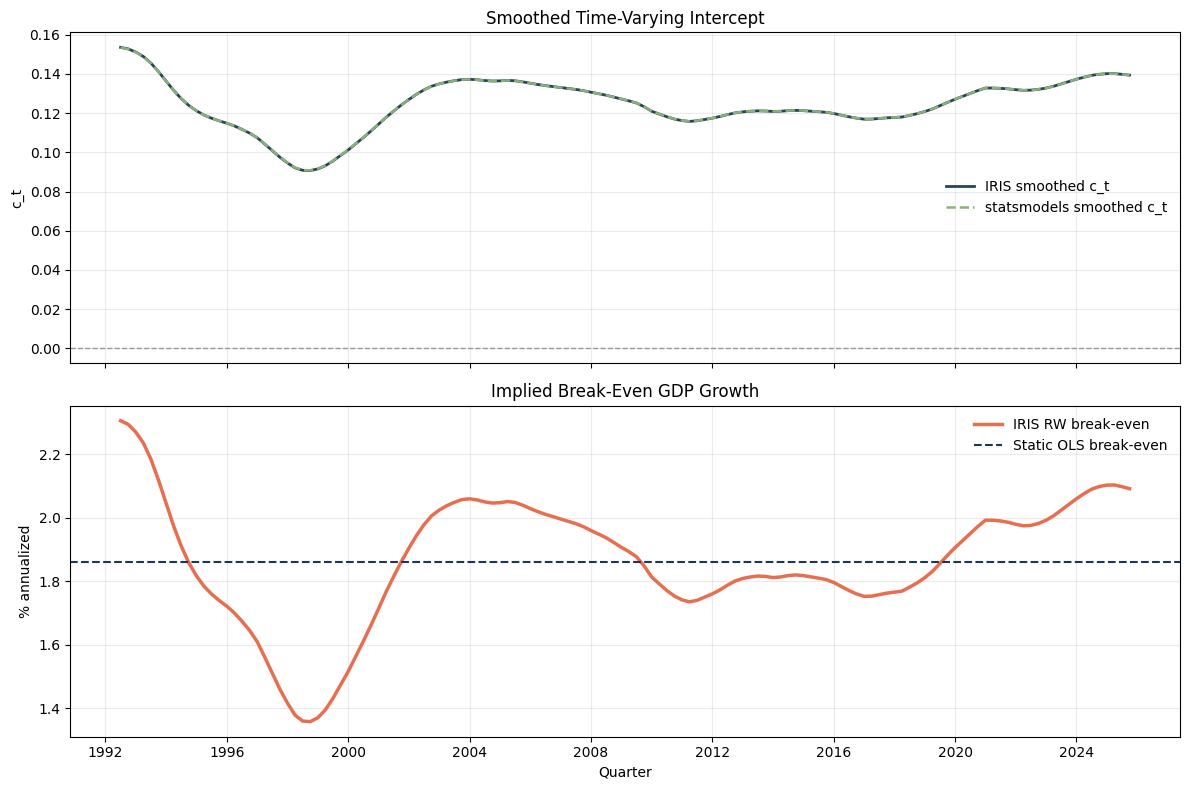

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(results_df['date'], results_df['c_t'], color='#264653', linewidth=2, label='IRIS smoothed c_t')
axes[0].plot(results_df['date'], results_df['tv_level_smoothed'], color='#8ab17d', linewidth=1.8, linestyle='--', label='statsmodels smoothed c_t')
axes[0].axhline(0, color='#999999', linestyle='--', linewidth=1)
axes[0].set_title('Smoothed Time-Varying Intercept')
axes[0].set_ylabel('c_t')
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(results_df['date'], results_df['break_even_growth_annualized_pct'], color='#e76f51', linewidth=2.5, label='IRIS RW break-even')
axes[1].axhline(static_break_even_annualized, color='#1d3557', linestyle='--', linewidth=1.5, label='Static OLS break-even')
axes[1].set_title('Implied Break-Even GDP Growth')
axes[1].set_ylabel('% annualized')
axes[1].set_xlabel('Quarter')
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## Save Results

In [11]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(OUTPUT_PATH, index=False)
OUTPUT_PATH

PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/outputs/time_varying_break_even_irispie_clean_rw.csv')

## Diffuse Method Check

In [12]:
comparison_df = pd.DataFrame([
    {
        'specification': 'IRIS fixed_unknown',
        'mean_break_even_qoq': float(results_df['break_even_growth_qoq_pct'].mean()),
        'std_break_even_qoq': float(results_df['break_even_growth_qoq_pct'].std(ddof=1)),
        'mean_break_even_annualized': float(results_df['break_even_growth_annualized_pct'].mean()),
        'std_break_even_annualized': float(results_df['break_even_growth_annualized_pct'].std(ddof=1)),
        'neg_log_likelihood': float(result.fun),
    },
    {
        'specification': 'IRIS approx_diffuse',
        'mean_break_even_qoq': np.nan,
        'std_break_even_qoq': np.nan,
        'mean_break_even_annualized': np.nan,
        'std_break_even_annualized': np.nan,
        'neg_log_likelihood': np.nan,
    },
])
comparison_df

,specification,mean_break_even_qoq,std_break_even_qoq,mean_break_even_annualized,std_break_even_annualized,neg_log_likelihood
0,IRIS fixed_unknown,0.462492,0.048507,1.862982,0.196655,468.343655
1,IRIS approx_diffuse,NaN,NaN,NaN,NaN,NaN


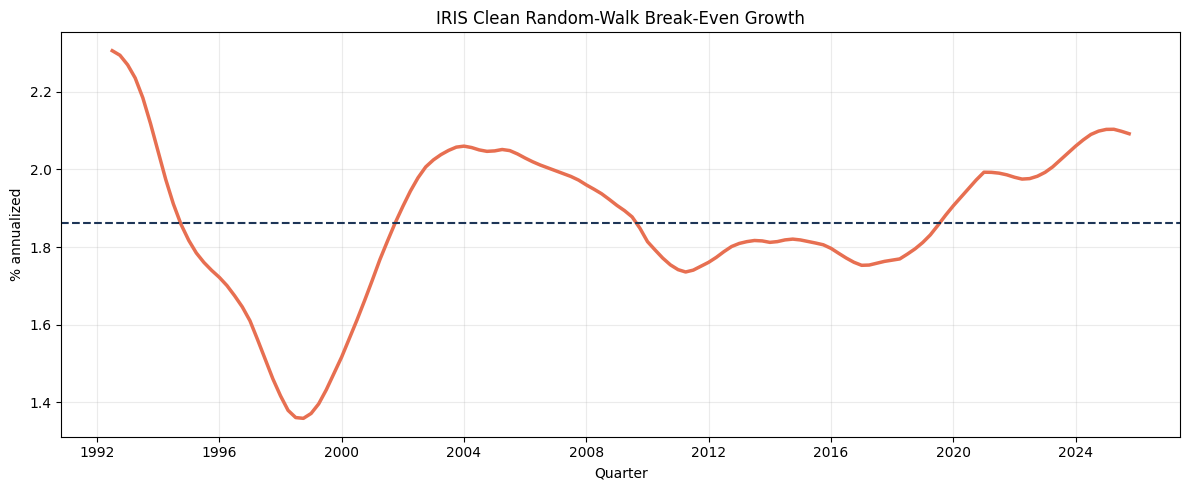

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_df['date'], results_df['break_even_growth_annualized_pct'], color='#e76f51', linewidth=2.5)
ax.axhline(static_break_even_annualized, color='#1d3557', linestyle='--', linewidth=1.5)
ax.set_title('IRIS Clean Random-Walk Break-Even Growth')
ax.set_ylabel('% annualized')
ax.set_xlabel('Quarter')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()